# 🔧 **MACHINE PREDICTIVE MAINTENANCE CLASSIFICATION**

## **Problem Statement**

Industrial machines often experience unexpected failures due to continuous operation and wear, leading to production downtime and increased maintenance costs. Traditional maintenance methods are not sufficient to prevent such failures. This project aims to build a machine learning–based classification model using sensor and operational data to predict machine failures and identify failure types in advance, enabling effective predictive maintenance and reducing operational disruptions.

---

## **Data Definition**

- **UDI:** Unique identifier assigned to each machine instance – *(Numerical)*  

- **Product ID:** Identifier representing the machine product type – *(Categorical)*  

- **Type:** Machine load type – *(L = Low, M = Medium, H = High)* – *(Categorical)*  

- **Air temperature [K]:** Ambient air temperature surrounding the machine during operation – *(Numerical)*  

- **Process temperature [K]:** Temperature measured during the machining process – *(Numerical)*  

- **Rotational speed [rpm]:** Speed at which the machine spindle rotates – *(Numerical)*  

- **Torque [Nm]:** Torque applied by the machine during operation – *(Numerical)*  

- **Tool wear [min]:** Accumulated tool usage time indicating tool degradation – *(Numerical)*  

- **Target:** Indicates whether a machine failure has occurred – *(Yes = 1, No = 0)* – *(Categorical / Binary)*  

- **Failure Type:** Specifies the category of machine failure –  
  *(Tool Wear Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, No Failure)* – *(Categorical / Multiclass)*

In [1]:
# =========================================================
# Suppress display of warnings
# =========================================================
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# Data handling and numerical computation
# =========================================================
# Pandas is used for data manipulation and analysis
import pandas as pd

# NumPy is used for numerical and mathematical operations
import numpy as np

# =========================================================
# Data visualization libraries
# =========================================================
# Matplotlib is used for plotting graphs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# Seaborn is used for statistical data visualization
import seaborn as sns

# =========================================================
# Data type checking utilities
# =========================================================
# To check if a column contains string (categorical) data
from pandas.api.types import is_string_dtype

# =========================================================
# Data preprocessing
# =========================================================
# Used to scale numerical features
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Used to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# =========================================================
# Machine Learning Models
# =========================================================

# Logistic Regression (Baseline model)
from sklearn.linear_model import LogisticRegression

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Random Forest Classifier (Ensemble - Bagging)
from sklearn.ensemble import RandomForestClassifier

# AdaBoost Classifier (Ensemble - Boosting)
from sklearn.ensemble import AdaBoostClassifier

# Gradient Boosting Classifier (Ensemble - Boosting)
from sklearn.ensemble import GradientBoostingClassifier

# Artificial Neural Network (ANN / MLP)
from sklearn.neural_network import MLPClassifier

# =========================================================
# Model evaluation metrics
# =========================================================
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# =========================================================
# Model optimization
# =========================================================
#SMOTE
from imblearn.over_sampling import SMOTE

# Used for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# read the excel data file 
df_machine = pd.read_csv('predictive_maintenance.csv')

# display the top 5 rows of the dataframe
df_machine.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


*** 
# The 'Target' column is removed because it is directly derived from 'Failure Types'.
# 'Failure Types' provides both failure occurrence and failure category, so it is used
# as the target variable to avoid data leakage and ensure realistic model performance.
***

In [3]:
# Drop 'Product ID, UDI & Target' column
df_machine = df_machine.drop(columns=['Product ID', 'UDI', 'Target'])
df_machine.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,M,298.1,308.6,1551,42.8,0,No Failure
1,L,298.2,308.7,1408,46.3,3,No Failure
2,L,298.1,308.5,1498,49.4,5,No Failure
3,L,298.2,308.6,1433,39.5,7,No Failure
4,L,298.2,308.7,1408,40.0,9,No Failure


**1. Check for the data type and Shape**

In [4]:
# 'dtypes' gives the data type for each column
df_machine.dtypes

Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Failure Type                object
dtype: object

In [5]:
df_machine.shape

(10000, 7)

**2 Summary Statistics**

In [6]:
# the describe() returns the statistical summary of the Numerical variables
df_machine.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [7]:
# the describe(include='object') returns the statistical summary of the Numerical variables
df_machine.describe(include='object')

,Type,Failure Type
count,10000,10000
unique,3,6
top,L,No Failure
freq,6000,9652


**2. Distribution of Variables**

Distribution of Numeric Independent Variables:


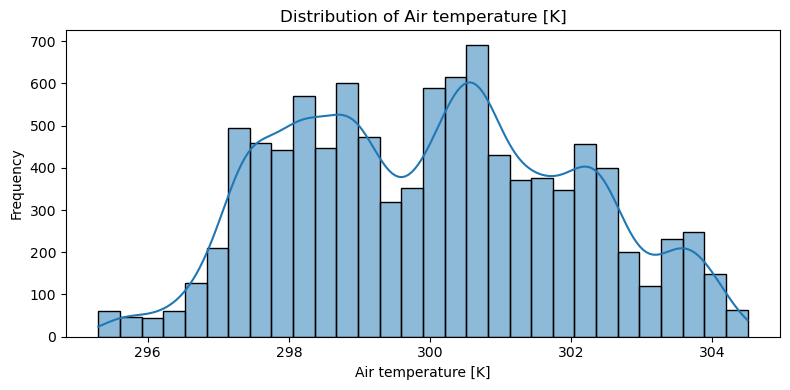

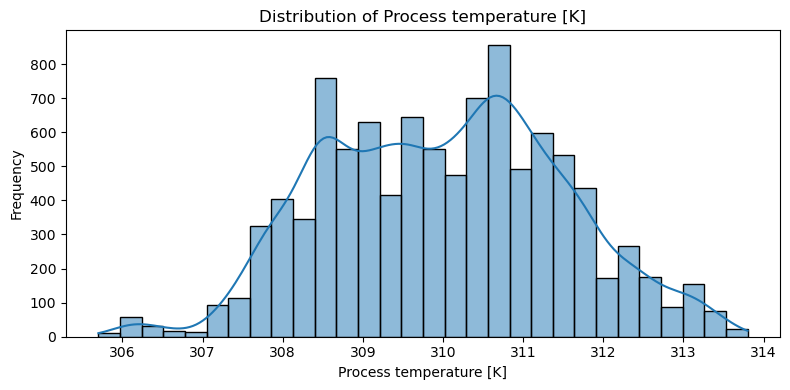

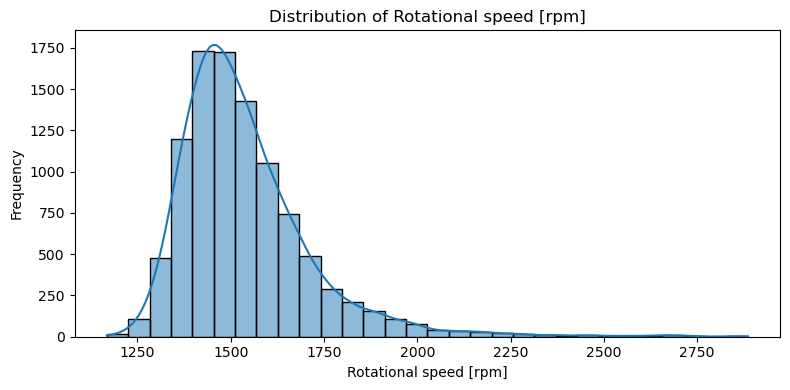

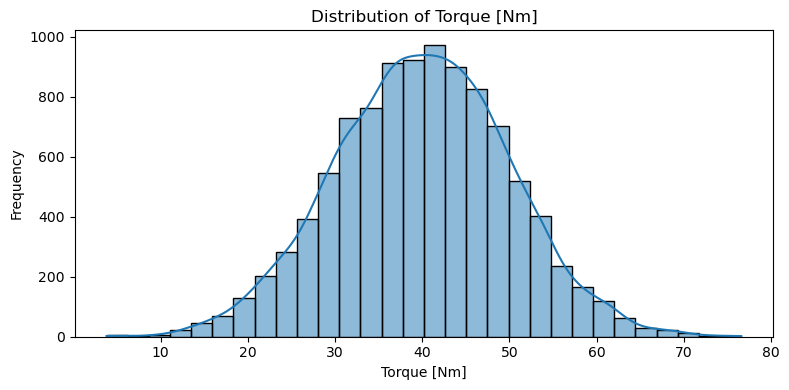

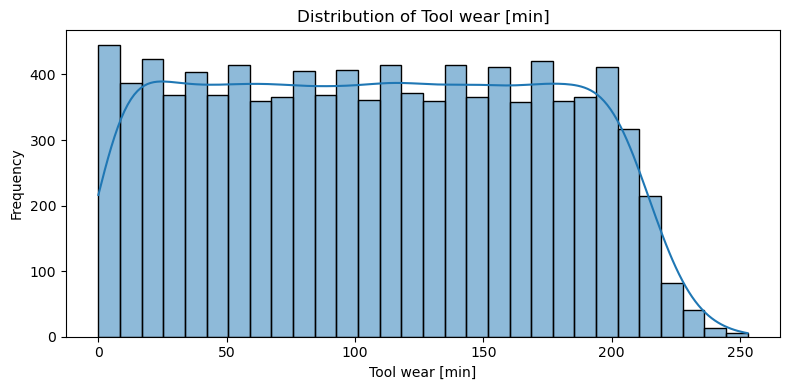

In [8]:
#Create folder if it doesn't exist
import os
os.makedirs("plots/histograms", exist_ok=True)

# Numeric independent variables
numeric_cols = df_machine.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target column
numeric_cols = [col for col in numeric_cols if col not in ['Target']]

# Plot histograms
if numeric_cols:
    print("Distribution of Numeric Independent Variables:")
    for col in numeric_cols:
        plt.figure(figsize=(8,4))
        sns.histplot(df_machine[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()

        # ✅ SAVE IMAGE (correct place)
        plt.savefig(
            f"plots/histograms/{col}_distribution.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
else:
    print("No numeric independent variables to display.")

Distribution of Categorical Independent Variables:


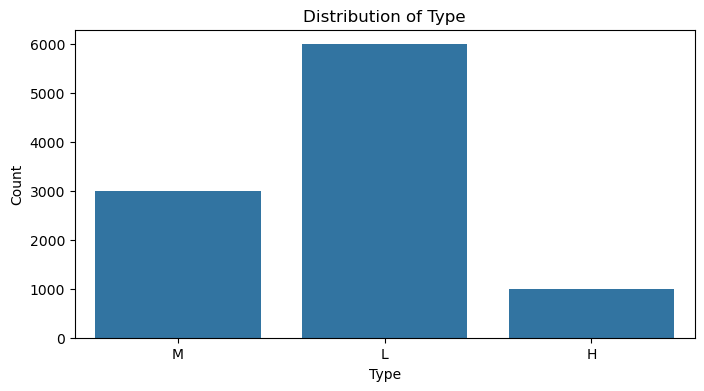

In [9]:
# Categorical independent variables
categorical_cols = df_machine.select_dtypes(include=['object']).columns.tolist()

# Remove target column
categorical_cols = [col for col in categorical_cols if col not in ['Failure Type']]

# Plot bar plots
if categorical_cols:
    print("Distribution of Categorical Independent Variables:")
    for col in categorical_cols:
        plt.figure(figsize=(8,4))
        sns.countplot(data=df_machine, x=col)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()
else:
    print("No categorical independent variables to display.")

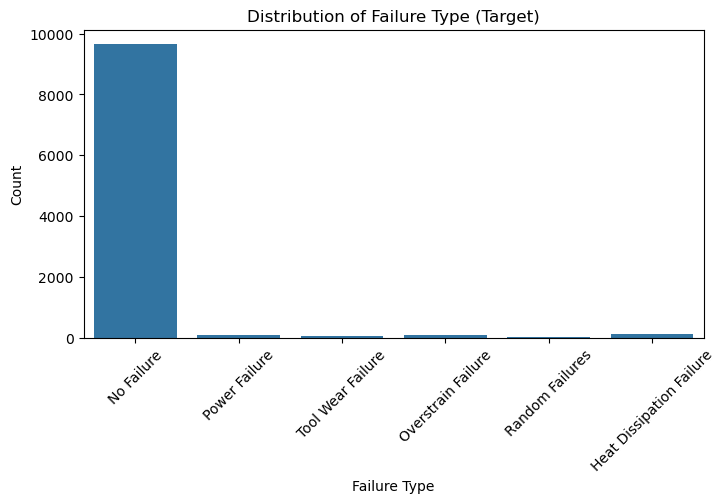

<Figure size 640x480 with 0 Axes>

In [10]:
if 'Failure Type' in df_machine.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df_machine, x='Failure Type')
    plt.title('Distribution of Failure Type (Target)')
    plt.xlabel('Failure Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# ✅ SAVE IMAGE
    plt.savefig(
        "plots/failure_type_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

**3. Missing Values**

In [11]:
# sort the variables on the basis of total null values in the variable
# 'isnull().sum()' returns the number of missing values in each variable
# 'ascending = False' sorts values in the descending order
# the variable with highest number of missing values will appear first
Total = df_machine.isnull().sum().sort_values(ascending = False)
Total

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Failure Type               0
dtype: int64

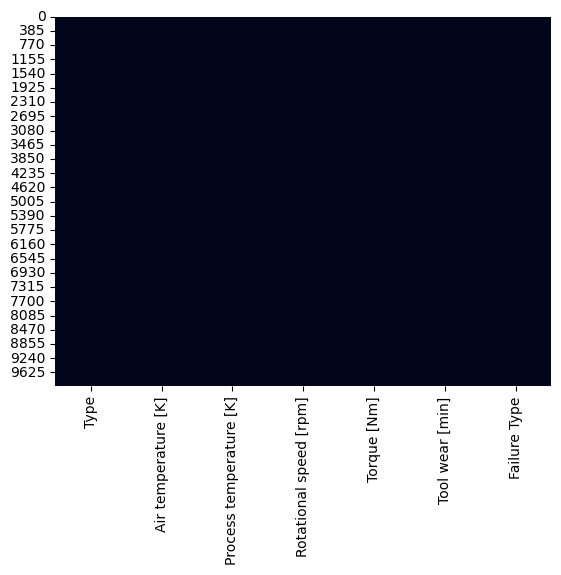

In [12]:
# plot heatmap to check null values
# 'cbar = False' does not show the color axis 
sns.heatmap(df_machine.isnull(), cbar=False)

# display the plot
plt.show()

**4. Identification and Removal of Outliers**

In [13]:
# Select numeric columns
numeric_cols = df_machine.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df_machine[col].quantile(0.25)
    Q3 = df_machine[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_machine[(df_machine[col] < lower_bound) | 
                           (df_machine[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

# Convert to DataFrame for easy viewing
outlier_df = pd.DataFrame.from_dict(
    outlier_summary, orient='index', columns=['Outlier_Count']
)

outlier_df

,Outlier_Count
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],418
Torque [Nm],69
Tool wear [min],0


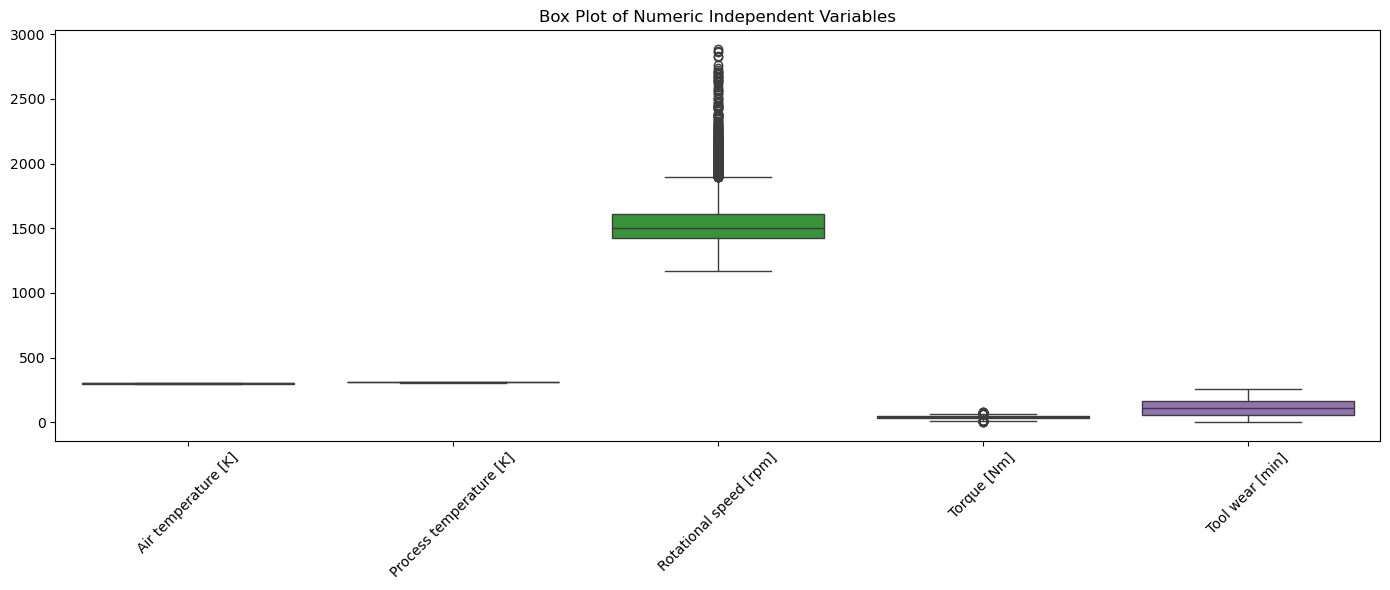

In [14]:
# Select only numeric columns
numeric_cols = df_machine.select_dtypes(include=['int64', 'float64'])

# Drop Target if present (important)
if 'Target' in numeric_cols.columns:
    numeric_cols = numeric_cols.drop(columns=['Target'])

# Plot boxplots for all numeric features
plt.figure(figsize=(14, 6))
sns.boxplot(data=numeric_cols)
plt.xticks(rotation=45)
plt.title("Box Plot of Numeric Independent Variables")
plt.tight_layout()
plt.show()

In [15]:
# Select numeric columns
numeric_cols = df_machine.select_dtypes(include=['int64', 'float64'])

# Do NOT remove outliers from target
numeric_cols = numeric_cols.drop(columns=['Target'], errors='ignore')

# IQR method
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

# Filter rows without outliers
df_no_outliers = df_machine[
    ~((numeric_cols < (Q1 - 1.5 * IQR)) | 
      (numeric_cols > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Original shape:", df_machine.shape)
print("After outlier removal:", df_no_outliers.shape)

Original shape: (10000, 7)
After outlier removal: (9541, 7)


**5. Conversion of Categorical data into Numerical data**

In [16]:
# ===========================
# 1️⃣ Explicit Target meaning
# ===========================

target_mapping = {0: 'No Failure', 1: 'Failure'}
print("Target Meaning:")
print(target_mapping)

# ===========================
# 2️⃣ Manual Failure Type Encoding
# ===========================

failure_type_mapping = {
    'No Failure': 0,
    'Heat Dissipation Failure': 1,
    'Power Failure': 2,
    'Overstrain Failure': 3,
    'Tool Wear Failure': 4,
    'Random Failures': 5
}

df_machine['Failure Types'] = df_machine['Failure Type'].map(failure_type_mapping)

print("\nFailure Type Encoding Mapping:")
print(failure_type_mapping)

# ===========================
# 3️⃣ Manual Type Encoding
# ===========================

type_mapping = {
    'L': 0,
    'M': 1,
    'H': 2
}

df_machine['Types'] = df_machine['Type'].map(type_mapping)

print("\nMachine Type Encoding Mapping:")
print(type_mapping)

# ===========================
# 4️⃣ Drop original categorical columns
# ===========================
df_machine = df_machine.drop(columns=['Failure Type', 'Type'])
df_machine.head()

Target Meaning:
{0: 'No Failure', 1: 'Failure'}

Failure Type Encoding Mapping:
{'No Failure': 0, 'Heat Dissipation Failure': 1, 'Power Failure': 2, 'Overstrain Failure': 3, 'Tool Wear Failure': 4, 'Random Failures': 5}

Machine Type Encoding Mapping:
{'L': 0, 'M': 1, 'H': 2}


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Types,Types
0,298.1,308.6,1551,42.8,0,0,1
1,298.2,308.7,1408,46.3,3,0,0
2,298.1,308.5,1498,49.4,5,0,0
3,298.2,308.6,1433,39.5,7,0,0
4,298.2,308.7,1408,40.0,9,0,0


**6. Splitting of Data and Fixing Imbalanced datasets**

In [17]:
# Count of Failure Type classes
failure_type_counts = df_machine['Failure Types'].value_counts()

print("Failure Type class distribution:")
print(failure_type_counts)

# Percentage distribution
print("\nFailure Type class percentage:")
print(df_machine['Failure Types'].value_counts(normalize=True) * 100)

Failure Type class distribution:
Failure Types
0    9652
1     112
2      95
3      78
4      45
5      18
Name: count, dtype: int64

Failure Type class percentage:
Failure Types
0    96.52
1     1.12
2     0.95
3     0.78
4     0.45
5     0.18
Name: proportion, dtype: float64


In [18]:
# ---------------------------
# 1. Remove extremely rare class (Class 5)
# ---------------------------
# Class 4, although small, was retained and addressed using resampling and class weighting.
# Class 5 has only 18 records in the dataset, which is extremely small compared 
# to other classes. Keeping such a tiny class can:
#   - Cause instability during model training
#   - Lead to poor performance or overfitting on that class
#   - Skew metrics due to very low representation
# Therefore, we remove class 5 to focus on the more meaningful classes.

df_machine = df_machine[df_machine['Failure Types'] != 5]

print("Class distribution after dropping class 5:\n")
print(df_machine['Failure Types'].value_counts())

Class distribution after dropping class 5:

Failure Types
0    9652
1     112
2      95
3      78
4      45
Name: count, dtype: int64


In [19]:
# Split features and target
# ===========================
X = df_machine.drop(columns=['Failure Types'])
y = df_machine['Failure Types']

# Train–test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# ===========================
# Apply SMOTE (TRAIN ONLY)
# ===========================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check distribution after SMOTE
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 Failure Types
0    7721
1      90
2      76
3      62
4      36
Name: count, dtype: int64

After SMOTE:
 Failure Types
0    7721
1    7721
4    7721
2    7721
3    7721
Name: count, dtype: int64


In [20]:
# ===========================
# Outlier Removal AFTER SMOTE (IQR Method)
# ===========================

import pandas as pd

# Convert SMOTE output to DataFrame
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = pd.Series(y_train_smote, name='Failure Types')

# Select numeric columns
numeric_cols = X_train_smote.select_dtypes(include=['int64', 'float64'])

# IQR calculation
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

# Create mask for non-outliers
non_outlier_mask = ~(
    (numeric_cols < (Q1 - 1.5 * IQR)) |
    (numeric_cols > (Q3 + 1.5 * IQR))
).any(axis=1)

# Remove outliers
X_train_smote = X_train_smote[non_outlier_mask]
y_train_smote = y_train_smote[non_outlier_mask]

print("Shape after outlier removal:", X_train_smote.shape)
print("Target shape after outlier removal:", y_train_smote.shape)

Shape after outlier removal: (26807, 6)
Target shape after outlier removal: (26807,)


**7. Feature scaling**

In [21]:
# Feature scaling for Multiclass target
# ===========================
scaler = StandardScaler()

# Fit scaler on TRAIN data only
X_train_smote_scaled = scaler.fit_transform(X_train_smote)

# Transform TEST data (do NOT fit again!)
X_test_scaled = scaler.transform(X_test)

**8. Model Building and Predicition using Different Classification Models**

In [22]:
# ===========================
# MultiClass Target Models (SMOTE)
# ===========================

print("\n========= Multi Class Target Models (SMOTE) =========\n")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Dictionary to store all SMOTE models
MODEL_SMOTE = {}

# 1️⃣ Logistic Regression
log_model = LogisticRegression(
    max_iter=500,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)
log_model.fit(X_train_smote_scaled, y_train_smote)
y_pred_log = log_model.predict(X_test_scaled)
print("Logistic Regression :\n", classification_report(y_test, y_pred_log))
MODEL_SMOTE["Logistic Regression"] = log_model


# 2️⃣ Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree :\n", classification_report(y_test, y_pred_dt))
MODEL_SMOTE["Decision Tree"] = dt_model


# 3️⃣ Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest :\n", classification_report(y_test, y_pred_rf))
MODEL_SMOTE["Random Forest"] = rf_model


# 4️⃣ AdaBoost
ab_model = AdaBoostClassifier(random_state=42)
ab_model.fit(X_train_smote, y_train_smote)
y_pred_ab = ab_model.predict(X_test)
print("AdaBoost :\n", classification_report(y_test, y_pred_ab))
MODEL_SMOTE["AdaBoost"] = ab_model


# 5️⃣ Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_smote, y_train_smote)
y_pred_gb = gb_model.predict(X_test)
print("Gradient Boosting :\n", classification_report(y_test, y_pred_gb))
MODEL_SMOTE["Gradient Boosting"] = gb_model


# 6️⃣ ANN / MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train_smote_scaled, y_train_smote)
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("ANN / MLP :\n", classification_report(y_test, y_pred_mlp))
MODEL_SMOTE["ANN / MLP"] = mlp_model


print("\n✅ All SMOTE models saved in MODEL_SMOTE dictionary")
print("Models stored:", list(MODEL_SMOTE.keys()))


========= Multi Class Target Models (SMOTE) =========

Logistic Regression :
               precision    recall  f1-score   support

           0       1.00      0.89      0.94      1931
           1       0.28      0.95      0.44        22
           2       0.65      0.79      0.71        19
           3       0.27      1.00      0.43        16
           4       0.05      0.67      0.10         9

    accuracy                           0.89      1997
   macro avg       0.45      0.86      0.52      1997
weighted avg       0.98      0.89      0.93      1997

Decision Tree :
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      1931
           1       0.69      0.91      0.78        22
           2       0.94      0.79      0.86        19
           3       0.45      0.62      0.53        16
           4       0.08      0.33      0.12         9

    accuracy                           0.96      1997
   macro avg       0.63      0.73  

**MODEL BUILDING AND PREDICTION BY APPLYING RANDOMOVER SAMPLER**

In [23]:
# ===========================
# Train–test split
# ===========================
from sklearn.model_selection import train_test_split

X = df_machine.drop(columns=['Failure Types'])
y = df_machine['Failure Types']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before RandomOverSampler:\n", y_train.value_counts())

# ===========================
# Apply RandomOverSampler (200)
# ===========================
from imblearn.over_sampling import RandomOverSampler

ros_strategy = {
    1: 200,
    2: 200,
    3: 200,
    4: 200
}

ros = RandomOverSampler(
    sampling_strategy=ros_strategy,
    random_state=42
)

X_ros, y_ros = ros.fit_resample(X_train, y_train)

print("\nAfter RandomOverSampler:\n", y_ros.value_counts())

# ===========================
# Feature scaling (for LR & ANN)
# ===========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_ros_scaled = scaler.fit_transform(X_ros)
X_test_scaled = scaler.transform(X_test)

# ===========================
# Models
# ===========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

print("\n========= RandomOverSampler (200) – Multiclass Models =========\n")

# Dictionary to store ROS(200) models
MODEL_ROS200 = {}

# 1️⃣ Logistic Regression
lr = LogisticRegression(
    max_iter=500,
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42
)
lr.fit(X_ros_scaled, y_ros)
lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression:\n", classification_report(y_test, lr_pred))
MODEL_ROS200["Logistic Regression"] = lr


# 2️⃣ Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_ros, y_ros)
dt_pred = dt.predict(X_test)
print("Decision Tree:\n", classification_report(y_test, dt_pred))
MODEL_ROS200["Decision Tree"] = dt


# 3️⃣ Balanced Random Forest
brf = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42
)
brf.fit(X_ros, y_ros)
brf_pred = brf.predict(X_test)
print("Balanced Random Forest:\n", classification_report(y_test, brf_pred))
MODEL_ROS200["Balanced Random Forest"] = brf


# 4️⃣ AdaBoost
ab = AdaBoostClassifier(random_state=42)
ab.fit(X_ros, y_ros)
ab_pred = ab.predict(X_test)
print("AdaBoost:\n", classification_report(y_test, ab_pred))
MODEL_ROS200["AdaBoost"] = ab


# 5️⃣ Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_ros, y_ros)
gb_pred = gb.predict(X_test)
print("Gradient Boosting:\n", classification_report(y_test, gb_pred))
MODEL_ROS200["Gradient Boosting"] = gb


# 6️⃣ ANN / MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_ros_scaled, y_ros)
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("ANN / MLP :\n", classification_report(y_test, y_pred_mlp))
MODEL_ROS200["ANN / MLP"] = mlp_model


print("\n✅ All ROS(200) models saved in MODEL_ROS200 dictionary")
print("Models stored:", list(MODEL_ROS200.keys()))

Before RandomOverSampler:
 Failure Types
0    7721
1      90
2      76
3      62
4      36
Name: count, dtype: int64

After RandomOverSampler:
 Failure Types
0    7721
1     200
4     200
2     200
3     200
Name: count, dtype: int64

========= RandomOverSampler (200) – Multiclass Models =========

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.86      0.93      1931
           1       0.25      1.00      0.40        22
           2       0.48      0.84      0.62        19
           3       0.34      0.94      0.50        16
           4       0.04      0.78      0.08         9

    accuracy                           0.87      1997
   macro avg       0.42      0.88      0.50      1997
weighted avg       0.98      0.87      0.91      1997

Decision Tree:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1931
           1       0.86      0.82      0.84        22
          

In [24]:
# ===========================
# Train–test split
# ===========================
from sklearn.model_selection import train_test_split

X = df_machine.drop(columns=['Failure Types'])
y = df_machine['Failure Types']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before RandomOverSampler:\n", y_train.value_counts())

# ===========================
# Apply RandomOverSampler (3861)
# ===========================
from imblearn.over_sampling import RandomOverSampler

ros_strategy = {
    1: 3861,
    2: 3861,
    3: 3861,
    4: 3861
}

ros = RandomOverSampler(
    sampling_strategy=ros_strategy,
    random_state=42
)

X_ros, y_ros = ros.fit_resample(X_train, y_train)

print("\nAfter RandomOverSampler:\n", y_ros.value_counts())

# ===========================
# Feature scaling (for LR & ANN)
# ===========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_ros_scaled = scaler.fit_transform(X_ros)
X_test_scaled = scaler.transform(X_test)

# ===========================
# Models
# ===========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

print("\n========= RandomOverSampler (3861) – Multiclass Models =========\n")

# Dictionary to store ROS(3861) models
MODEL_ROS3861 = {}

# 1️⃣ Logistic Regression
lr = LogisticRegression(
    max_iter=500,
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42
)
lr.fit(X_ros_scaled, y_ros)
lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression:\n", classification_report(y_test, lr_pred))
MODEL_ROS3861["Logistic Regression"] = lr


# 2️⃣ Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_ros, y_ros)
dt_pred = dt.predict(X_test)
print("Decision Tree:\n", classification_report(y_test, dt_pred))
MODEL_ROS3861["Decision Tree"] = dt


# 3️⃣ Balanced Random Forest
brf = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42
)
brf.fit(X_ros, y_ros)
brf_pred = brf.predict(X_test)
print("Balanced Random Forest:\n", classification_report(y_test, brf_pred))
MODEL_ROS3861["Balanced Random Forest"] = brf


# 4️⃣ AdaBoost
ab = AdaBoostClassifier(random_state=42)
ab.fit(X_ros, y_ros)
ab_pred = ab.predict(X_test)
print("AdaBoost:\n", classification_report(y_test, ab_pred))
MODEL_ROS3861["AdaBoost"] = ab


# 5️⃣ Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_ros, y_ros)
gb_pred = gb.predict(X_test)
print("Gradient Boosting:\n", classification_report(y_test, gb_pred))
MODEL_ROS3861["Gradient Boosting"] = gb


# 6️⃣ ANN / MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_ros_scaled, y_ros)
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("ANN / MLP :\n", classification_report(y_test, y_pred_mlp))
MODEL_ROS3861["ANN / MLP"] = mlp_model


print("\n✅ All ROS(3861) models saved in MODEL_ROS3861 dictionary")
print("Models stored:", list(MODEL_ROS3861.keys()))

Before RandomOverSampler:
 Failure Types
0    7721
1      90
2      76
3      62
4      36
Name: count, dtype: int64

After RandomOverSampler:
 Failure Types
0    7721
1    3861
4    3861
2    3861
3    3861
Name: count, dtype: int64

========= RandomOverSampler (3861) – Multiclass Models =========

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93      1931
           1       0.27      1.00      0.42        22
           2       0.43      0.84      0.57        19
           3       0.33      0.88      0.48        16
           4       0.04      0.67      0.08         9

    accuracy                           0.87      1997
   macro avg       0.41      0.85      0.50      1997
weighted avg       0.98      0.87      0.91      1997

Decision Tree:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1931
           1       0.79      0.86      0.83        22
         

In [25]:
# Models that require scaled input
SCALED_MODELS = ["Logistic Regression", "ANN / MLP"]

# Function to evaluate models
def evaluate_all_models(models_dict, X_test, X_test_scaled, y_test, sampling_name):
    rows = []
    for model_name, model in models_dict.items():
        if model_name in SCALED_MODELS:
            y_pred = model.predict(X_test_scaled)
        else:
            y_pred = model.predict(X_test)

        rows.append({
            "Sampling Technique": sampling_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (Macro)": precision_score(y_test, y_pred, average="macro"),
            "Recall (Macro)": recall_score(y_test, y_pred, average="macro"),
            "F1-score (Macro)": f1_score(y_test, y_pred, average="macro")
        })
    return rows

# ===========================
# Evaluate all models
# ===========================
results = []
results += evaluate_all_models(MODEL_SMOTE, X_test, X_test_scaled, y_test, "SMOTE")
results += evaluate_all_models(MODEL_ROS200, X_test, X_test_scaled, y_test, "ROS200")
results += evaluate_all_models(MODEL_ROS3861, X_test, X_test_scaled, y_test, "ROS3861")

comparison_df = pd.DataFrame(results)

# ===========================
# Display full comparison
# ===========================
print("\n========= FULL MODEL COMPARISON =========\n")
print(comparison_df)

# ===========================
# Top 5 best models (based on Macro F1-score)
# ===========================
top5_models = comparison_df.sort_values("F1-score (Macro)", ascending=False).head(5)

print("\n========= TOP 5 BEST MODELS =========\n")
print(top5_models[['Model', 'Sampling Technique', 'Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-score (Macro)']])

# Save the top 5 models Excel file inside the folder
top5_models.to_excel("plots/top5_models.xlsx", index=False)


========= FULL MODEL COMPARISON =========

   Sampling Technique                   Model  Accuracy  Precision (Macro)  \
0               SMOTE     Logistic Regression  0.757136           0.309786   
1               SMOTE           Decision Tree  0.963946           0.630244   
2               SMOTE           Random Forest  0.964447           0.602950   
3               SMOTE                AdaBoost  0.912369           0.423933   
4               SMOTE       Gradient Boosting  0.947421           0.605568   
5               SMOTE               ANN / MLP  0.911868           0.424104   
6              ROS200     Logistic Regression  0.964447           0.355076   
7              ROS200           Decision Tree  0.979970           0.715562   
8              ROS200  Balanced Random Forest  0.912869           0.458275   
9              ROS200                AdaBoost  0.969955           0.438912   
10             ROS200       Gradient Boosting  0.989484           0.820273   
11             ROS20

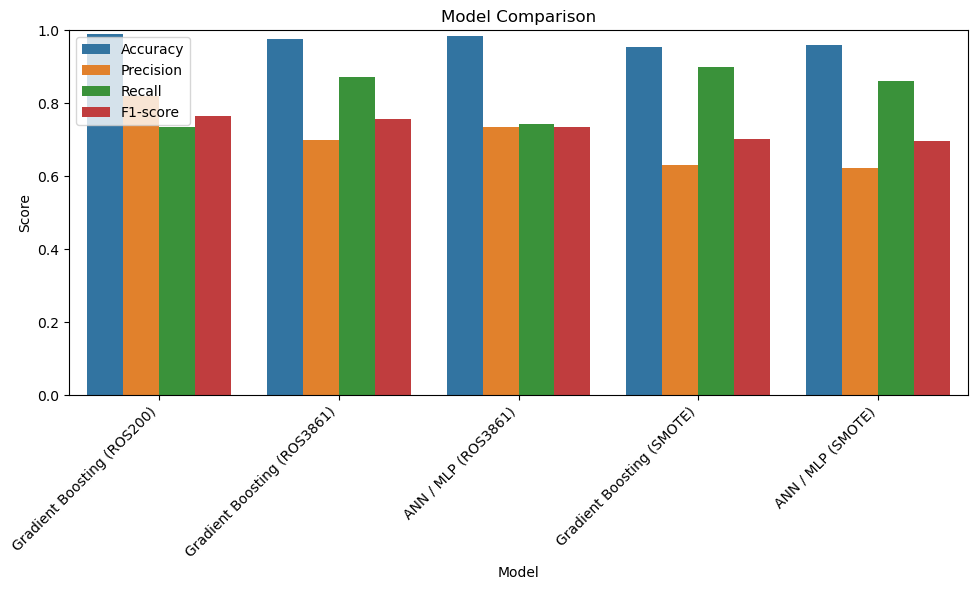

In [26]:
#COMPARISON OF PERFORMANCE METRICS FOR THE TOP 5 MODELS
data = {
    "Model": [
        "Gradient Boosting (ROS200)",
        "Gradient Boosting (ROS3861)",
        "ANN / MLP (ROS3861)",
        "Gradient Boosting (SMOTE)",
        "ANN / MLP (SMOTE)"
    ],
    "Accuracy": [0.989, 0.976, 0.984, 0.953, 0.961],
    "Precision": [0.82, 0.699, 0.734, 0.632, 0.624],
    "Recall": [0.734, 0.873, 0.744, 0.9, 0.861],
    "F1-score": [0.765, 0.757, 0.735, 0.701, 0.697]
}

df = pd.DataFrame(data)

# Melt the dataframe for seaborn
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)
plt.legend(loc="upper left")
plt.tight_layout()

# Save first
plt.savefig("plots/model_comparison.png", dpi=300, bbox_inches="tight")

# Then show
plt.show()


================ Gradient Boosting (ROS200) ================

Confusion Matrix:



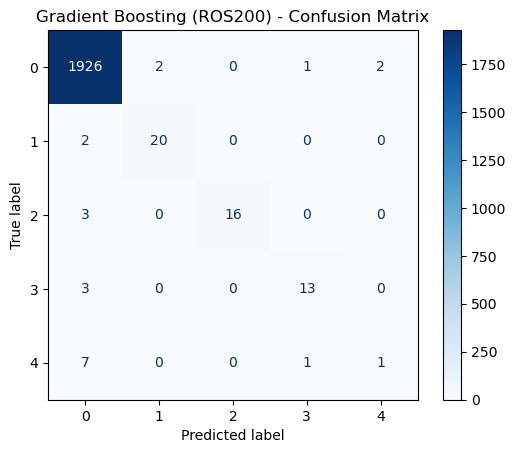

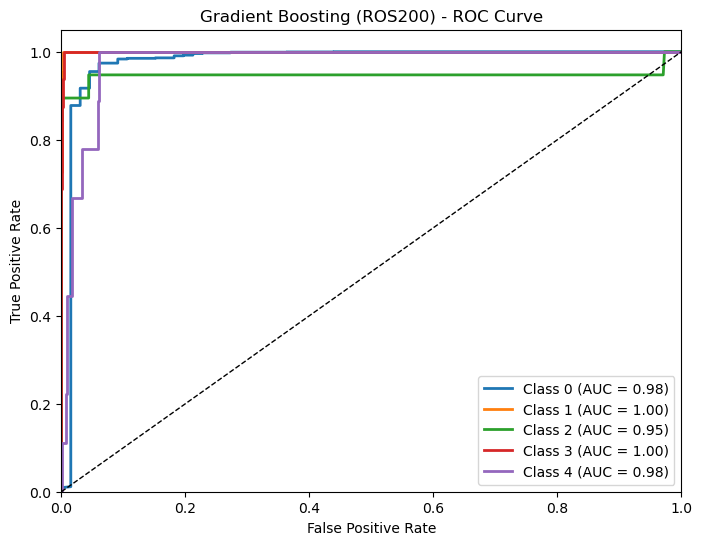


================ Gradient Boosting (ROS3861) ================

Confusion Matrix:



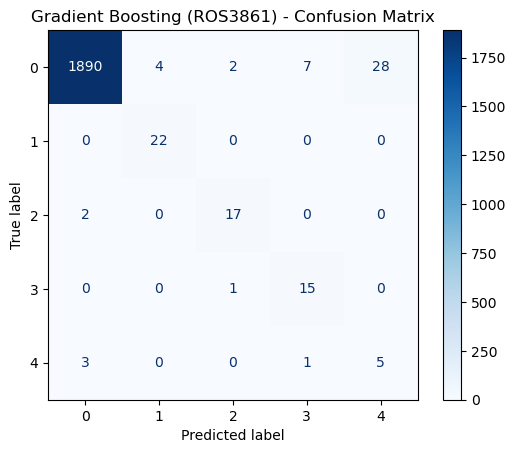

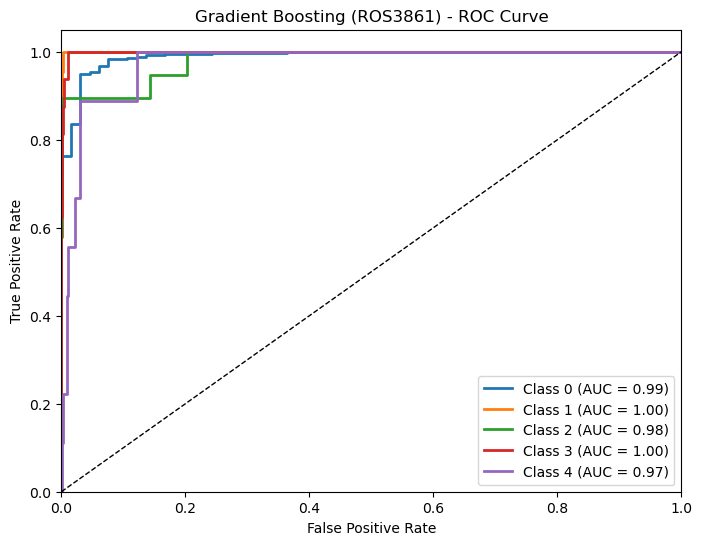


================ ANN / MLP (ROS3861) ================

Confusion Matrix:



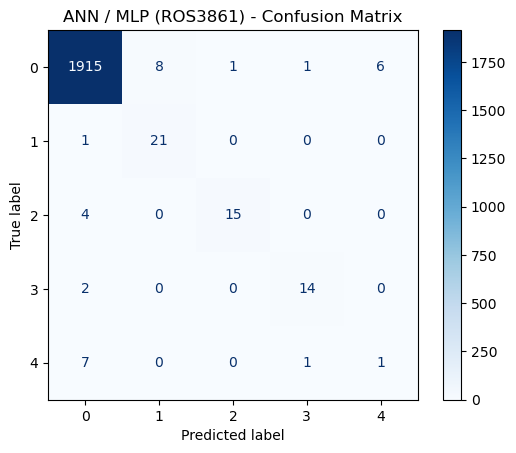

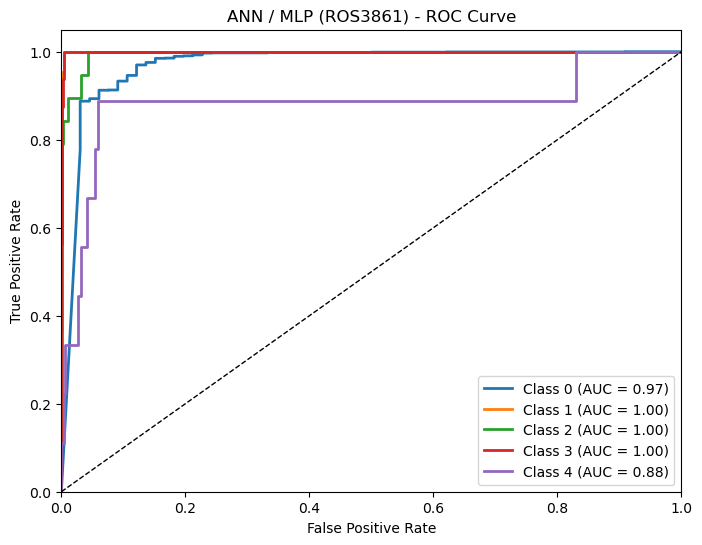


================ Gradient Boosting (SMOTE) ================

Confusion Matrix:



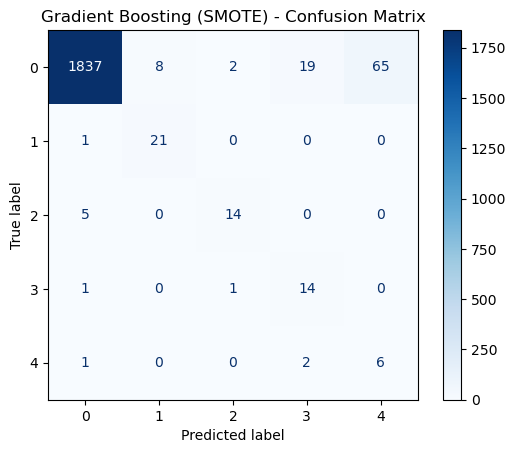

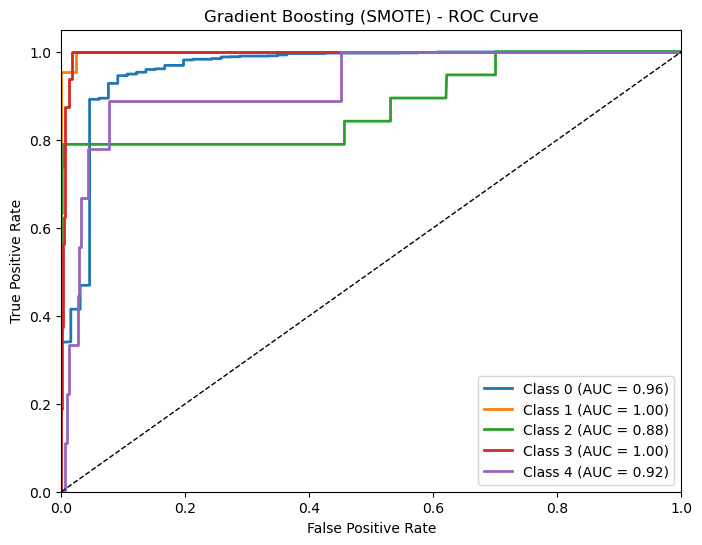


================ ANN / MLP (SMOTE) ================

Confusion Matrix:



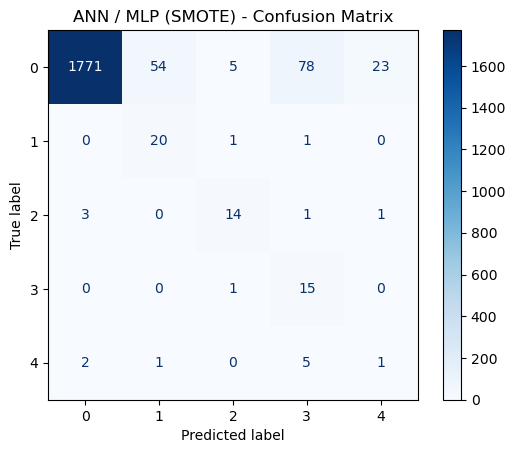

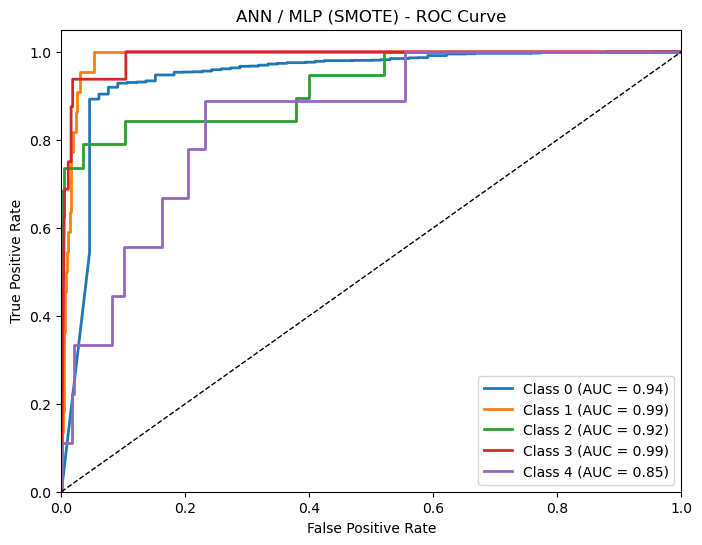

In [27]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import re

# -----------------------------
# Ensure the plots folder exists
# -----------------------------
os.makedirs("plots", exist_ok=True)

# Function to safely create a filename
def safe_filename(name):
    # Replace any character that is not alphanumeric or underscore with _
    return re.sub(r'[^\w\-]', '_', name)

# -----------------------------
# Top 5 models from previous ranking
# -----------------------------
top5_models_list = [
    ("Gradient Boosting", "ROS200", MODEL_ROS200["Gradient Boosting"]),
    ("Gradient Boosting", "ROS3861", MODEL_ROS3861["Gradient Boosting"]),
    ("ANN / MLP", "ROS3861", MODEL_ROS3861["ANN / MLP"]),
    ("Gradient Boosting", "SMOTE", MODEL_SMOTE["Gradient Boosting"]),
    ("ANN / MLP", "SMOTE", MODEL_SMOTE["ANN / MLP"])
]

# Binarize y_test for multiclass ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Models that require scaled input
SCALED_MODELS = ["Logistic Regression", "ANN / MLP"]

# -----------------------------
# Loop through each top model
# -----------------------------
for model_name, sampling, model in top5_models_list:
    print(f"\n================ {model_name} ({sampling}) ================\n")
    
    # Prediction
    if model_name in SCALED_MODELS:
        y_pred = model.predict(X_test_scaled)
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)
    
    # ---------------------------
    # Confusion Matrix
    # ---------------------------
    print("Confusion Matrix:\n")
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=classes,
        cmap=plt.cm.Blues,
        values_format='d'
    )
    plt.title(f"{model_name} ({sampling}) - Confusion Matrix")
    
    # Safe filename
    cm_file = safe_filename(f"CM_{model_name}_{sampling}.png")
    cm_path = os.path.join("plots", cm_file)
    
    # Save BEFORE show
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    # ---------------------------
    # ROC Curve (multiclass)
    # ---------------------------
    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ({sampling}) - ROC Curve")
    plt.legend(loc="lower right")
    
    # Safe filename
    roc_file = safe_filename(f"ROC_{model_name}_{sampling}.png")
    roc_path = os.path.join("plots", roc_file)
    
    # Save BEFORE show
    plt.savefig(roc_path, dpi=300, bbox_inches="tight")
    plt.show()